<a href="https://colab.research.google.com/github/wangemma777/GridPACK-file-conversion/blob/main/GridPACK_Data_Analysis_with_CuDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q cudf-cu12 dask-cudf-cu12 matplotlib pandas

from google.colab import drive
drive.mount("/content/drive")

import dask_cudf
import matplotlib.pyplot as plt

MERGED_FILE = "/content/drive/MyDrive/merged_branches_with_area.parquet"
PARTITIONED_OUT = "/content/drive/MyDrive/merged_branches_partitioned"

cols = [
    "contingency",
    "from_bus",
    "to_bus",
    "circuit_id",
    "loading_percent",
    "from_area",
    "from_area_name",
    "from_base_kv",
    "to_area",
    "to_area_name",
    "to_base_kv",
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#only need to run once to produce folders in Google Drive, longest processing step
#reads merged parquet file
ddf = dask_cudf.read_parquet(
    MERGED_FILE,
    columns=cols,
    split_row_groups=True,
    blocksize="64MB",
)

#partitions large merged file
ddf = ddf.repartition(npartitions=200)

ddf.to_parquet(
    PARTITIONED_OUT,
    write_index=False,
    compression="snappy",
    write_metadata_file=False,
)

KeyboardInterrupt: 

In [ ]:
#reads partitioned parquet files
ddf = dask_cudf.read_parquet(
    "/content/drive/MyDrive/merged_branches_partitioned",
    columns=cols,
    split_row_groups=True,
    blocksize="64MB",
)

print("Partitions:", ddf.npartitions)

Partitions: 200


In [ ]:
#adds "overloaded" column for easier analysis
def normalize_columns(ddf):
    return ddf.assign(
        overloaded=ddf.loading_percent >= 100.0
    )

ddf = normalize_columns(ddf)

#persists so later functions can use additional column
ddf = ddf.persist()


In [ ]:
#grouping functions

#groups by branch
def group_by_branch(ddf):
    """
    Groups by physical branch using numeric columns.
    Faster than grouping by string branch_id.
    """
    return (
        ddf.groupby(["from_bus", "to_bus", "circuit_id"])
        .agg({
            "contingency": "count",
            "overloaded": "sum",
            "loading_percent": "max",
            "from_area_name": "first",
            "to_area_name": "first",
        })
        .rename(columns={
            "contingency": "num_contingencies",
            "overloaded": "num_overloads",
            "loading_percent": "max_loading_pct",
        })
        .reset_index()
    )

#groups by from area
def group_by_from_area(ddf):
    return (
        ddf.groupby("from_area_name")
        .agg({
            "contingency": "count",
            "overloaded": "sum",
            "loading_percent": "max",
        })
        .rename(columns={
            "contingency": "num_records",
            "overloaded": "num_overloads",
            "loading_percent": "max_loading_pct",
        })
        .reset_index()
    )

#groups by area pairs
def group_by_area_pair(ddf):
    return (
        ddf.groupby(["from_area_name", "to_area_name"])
        .agg({
            "contingency": "count",
            "overloaded": "sum",
            "loading_percent": "max",
        })
        .rename(columns={
            "contingency": "num_records",
            "overloaded": "num_overloads",
            "loading_percent": "max_loading_pct",
        })
        .reset_index()
    )

#groups by contigency
def group_by_contingency(ddf):
    return (
        ddf.groupby("contingency")
        .agg({
            "overloaded": "sum",
            "loading_percent": "max",
        })
        .rename(columns={
            "overloaded": "num_overloaded_branches",
            "loading_percent": "max_loading_pct",
        })
        .reset_index()
    )

#groups by voltage
def group_by_voltage(ddf):
    return (
        ddf.groupby("from_base_kv")
        .agg({
            "contingency": "count",
            "overloaded": "sum",
            "loading_percent": "max",
        })
        .rename(columns={
            "contingency": "num_records",
            "overloaded": "num_overloads",
            "loading_percent": "max_loading_pct",
        })
        .reset_index()
    )

#groups by voltage pair
def group_by_voltage_pair(ddf):
    return (
        ddf.groupby(["from_base_kv", "to_base_kv"])
        .agg({
            "contingency": "count",
            "overloaded": "sum",
            "loading_percent": "max",
        })
        .rename(columns={
            "contingency": "num_records",
            "overloaded": "num_overloads",
            "loading_percent": "max_loading_pct",
        })
        .reset_index()
    )

In [ ]:
#filtering functions
def filter_overloaded(ddf):
    return ddf[ddf.overloaded]


def filter_loading_threshold(ddf, threshold=100):
    return ddf[ddf.loading_percent >= threshold]


def filter_by_from_area(ddf, area_name):
    return ddf[ddf.from_area_name == area_name]


def filter_by_to_area(ddf, area_name):
    return ddf[ddf.to_area_name == area_name]


def filter_by_area(ddf, area_name):
    return ddf[
        (ddf.from_area_name == area_name) |
        (ddf.to_area_name == area_name)
    ]


def filter_by_area_pair(ddf, from_area, to_area):
    return ddf[
        (ddf.from_area_name == from_area) &
        (ddf.to_area_name == to_area)
    ]


def filter_by_contingency(ddf, contingency):
    return ddf[ddf.contingency == contingency]

In [ ]:
#ranks top data
def top_branches_by_loading(ddf, n=20):
    branch_summary = group_by_branch(ddf)
    return branch_summary.nlargest(n, "max_loading_pct")


def top_branches_by_overloads(ddf, n=20):
    branch_summary = group_by_branch(ddf)
    return branch_summary.nlargest(n, "num_overloads")


def top_areas_by_overloads(ddf, n=20):
    area_summary = group_by_from_area(ddf)
    return area_summary.nlargest(n, "num_overloads")


def top_area_pairs_by_overloads(ddf, n=20):
    area_pair_summary = group_by_area_pair(ddf)
    return area_pair_summary.nlargest(n, "num_overloads")


def top_contingencies_by_overloads(ddf, n=20):
    contingency_summary = group_by_contingency(ddf)
    return contingency_summary.nlargest(n, "num_overloaded_branches")

In [ ]:
def plot_bar(pdf, x_col, y_col, title, xlabel, ylabel):
    pdf = pdf.to_pandas() if hasattr(pdf, "to_pandas") else pdf

    plt.figure(figsize=(10, 6))
    plt.barh(pdf[x_col].astype(str), pdf[y_col])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [ ]:
# records max utilization across contingencies in a branch
branch_max_utilization = (
    ddf.groupby(["from_bus", "to_bus", "circuit_id"])
    .agg({
        "loading_percent": "max",
        "from_area_name": "first",
        "to_area_name": "first",
    })
    .rename(columns={
        "loading_percent": "branch_max_utilization"
    })
    .reset_index()
)

#groups branches by area and averages max utilization
area_avg_branch_max = (
    branch_max_utilization
    .groupby("from_area_name")
    .agg({
        "branch_max_utilization": "mean"
    })
    .rename(columns={
        "branch_max_utilization": "avg_branch_max_utilization"
    })
    .reset_index()
)

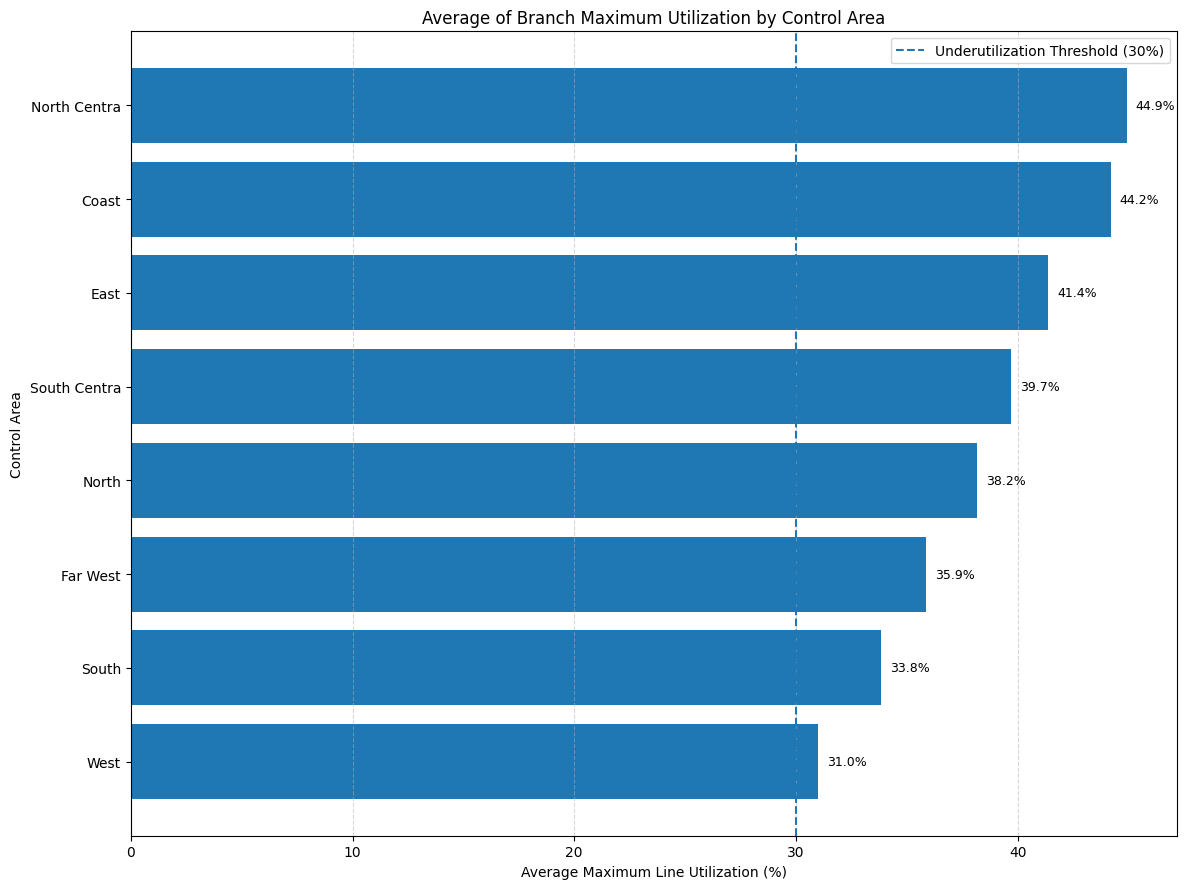

In [ ]:
#produces graph for average max utilization across an area
top_areas = (
    area_avg_branch_max
    .nlargest(25, "avg_branch_max_utilization")
    .compute()
    .to_pandas()
)

top_areas = top_areas.sort_values(
    "avg_branch_max_utilization",
    ascending=True
)

plt.figure(figsize=(12, 9))

plt.barh(
    top_areas["from_area_name"],
    top_areas["avg_branch_max_utilization"]
)

plt.axvline(
    x=30,
    linestyle="--",
    linewidth=1.5,
    label="Underutilization Threshold (30%)"
)

for i, value in enumerate(top_areas["avg_branch_max_utilization"]):
    plt.text(
        value + 0.4,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.title("Average of Branch Maximum Utilization by Control Area")
plt.xlabel("Average Maximum Line Utilization (%)")
plt.ylabel("Control Area")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()